# 10 GHz Phase-Randomised GS-DFB — Interactive Re-plotting

Loads 1M-pulse frequency sweep data from `images/acceptance_bw_comparison/data/`
and power sweep / spectra / detection chain from `images/paper_10ghz/data/`.

Each figure section has **tweakable parameters** in a clearly marked cell. Edit those and re-run.

In [144]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ── 1M-pulse frequency sweep (acceptance BW comparison) ───────
ABW_DATA = Path('../images/acceptance_bw_comparison/data')
ACCEPTANCE_BW = 0.7   # nm — change to 0.7 or 3.0 to switch

free_1m = np.load(ABW_DATA / 'free_running.npz', allow_pickle=True)
sld_1m  = np.load(ABW_DATA / f'sld_bw{ACCEPTANCE_BW:.1f}nm.npz', allow_pickle=True)
scalars = json.loads((ABW_DATA / f'scalars_bw{ACCEPTANCE_BW:.1f}nm.json').read_text())

freq_labels = list(free_1m['freq_labels'])
N_PULSES = int(free_1m['N_PULSES'])

# Build unified dict matching the key pattern used by figures:
#   '{flabel}_{free|sld}_eta', '{flabel}_{free|sld}_autocorr', etc.
freq_sweep = {}
for flabel in freq_labels:
    for suffix in ['eta', 'dphi', 'autocorr', 'eta_autocorr']:
        freq_sweep[f'{flabel}_free_{suffix}'] = free_1m[f'{flabel}_{suffix}']
        freq_sweep[f'{flabel}_sld_{suffix}']  = sld_1m[f'{flabel}_{suffix}']

print(f'Frequencies: {freq_labels}')
print(f'N_PULSES = {N_PULSES:,}  (acceptance BW = {ACCEPTANCE_BW} nm)')

# ── Paper 10 GHz data (power sweep, spectra, detection chain) ─
DATA = Path('../images/paper_10ghz/data')
OUT  = Path('../images/paper_10ghz')

params       = json.loads((DATA / 'parameters.json').read_text())
power_sweep  = np.load(DATA / 'power_sweep.npz')
mechanism    = np.load(DATA / 'mechanism.npz')
det_1g       = np.load(DATA / 'detection_1_GHz_free.npz')
det_10g      = np.load(DATA / 'detection_10_GHz_plus_SLD.npz')
det_enob     = np.load(DATA / 'detection_enob_sweep.npz')

spec_data = {}
for p in DATA.glob('spectrum_*.npz'):
    key = p.stem.replace('spectrum_', '').replace('_', ' ')
    spec_data[key] = np.load(p)

print(f'Spectrum configs: {list(spec_data.keys())}')

Frequencies: [np.str_('1 GHz'), np.str_('2 GHz'), np.str_('5 GHz'), np.str_('8 GHz'), np.str_('10 GHz')]
N_PULSES = 1,000,000  (acceptance BW = 0.7 nm)
Spectrum configs: ['1 GHz sld', '10 GHz free', '1 GHz free', '10 GHz sld']


In [145]:
# Helpers

def eta_autocorrelation(eta, max_lag=50):
    """Compute normalised autocovariance of eta."""
    c = eta - np.mean(eta)
    v = np.var(eta)
    if v < 1e-30:
        return np.zeros(max_lag)
    ac = np.empty(max_lag)
    ac[0] = 1.0
    for k in range(1, max_lag):
        ac[k] = np.mean(c[k:] * c[:-k]) / v
    return ac

def autocorr_ci(n, confidence=0.99):
    """Rayleigh-based CI for |r_k| under H0: uniform iid phases."""
    return np.sqrt(-np.log(1.0 - confidence) / n)

def bartlett_ci(n, confidence=0.99):
    """Bartlett CI for eta autocorrelation: ±z_{alpha/2}/sqrt(N)."""
    from scipy.stats import norm
    z = norm.ppf(1 - (1 - confidence) / 2)
    return z / np.sqrt(n)

# Theoretical arcsine PDF
eta_th = np.linspace(0.001, 0.999, 500)
arcsine_pdf = 1.0 / (np.pi * np.sqrt(eta_th * (1.0 - eta_th)))

In [146]:
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})

---
## Figure 1 — AMZI Histograms + η Autocorrelation

In [121]:
# ─── Tweakable parameters ───────────────────────────────────────
FIG1_BINS       = 256
FIG1_YLIM_HIST  = 12e-3
FIG1_MAX_LAG    = 100
FIG1_CI_LEVEL   = 0.99       # confidence level for eta autocorrelation
FIG1_FIGSIZE    = (4, 3.5)   # per-panel size (width, height)
FIG1_HIST_ALPHA = 0.7
FIG1_DPI        = 150
FIG1_SAVE       = False
# ────────────────────────────────────────────────────────────────

In [128]:
freq_labels = freq_labels[0::2]

In [129]:
freq_labels

['1 GHz', '5 GHz', '10 GHz']

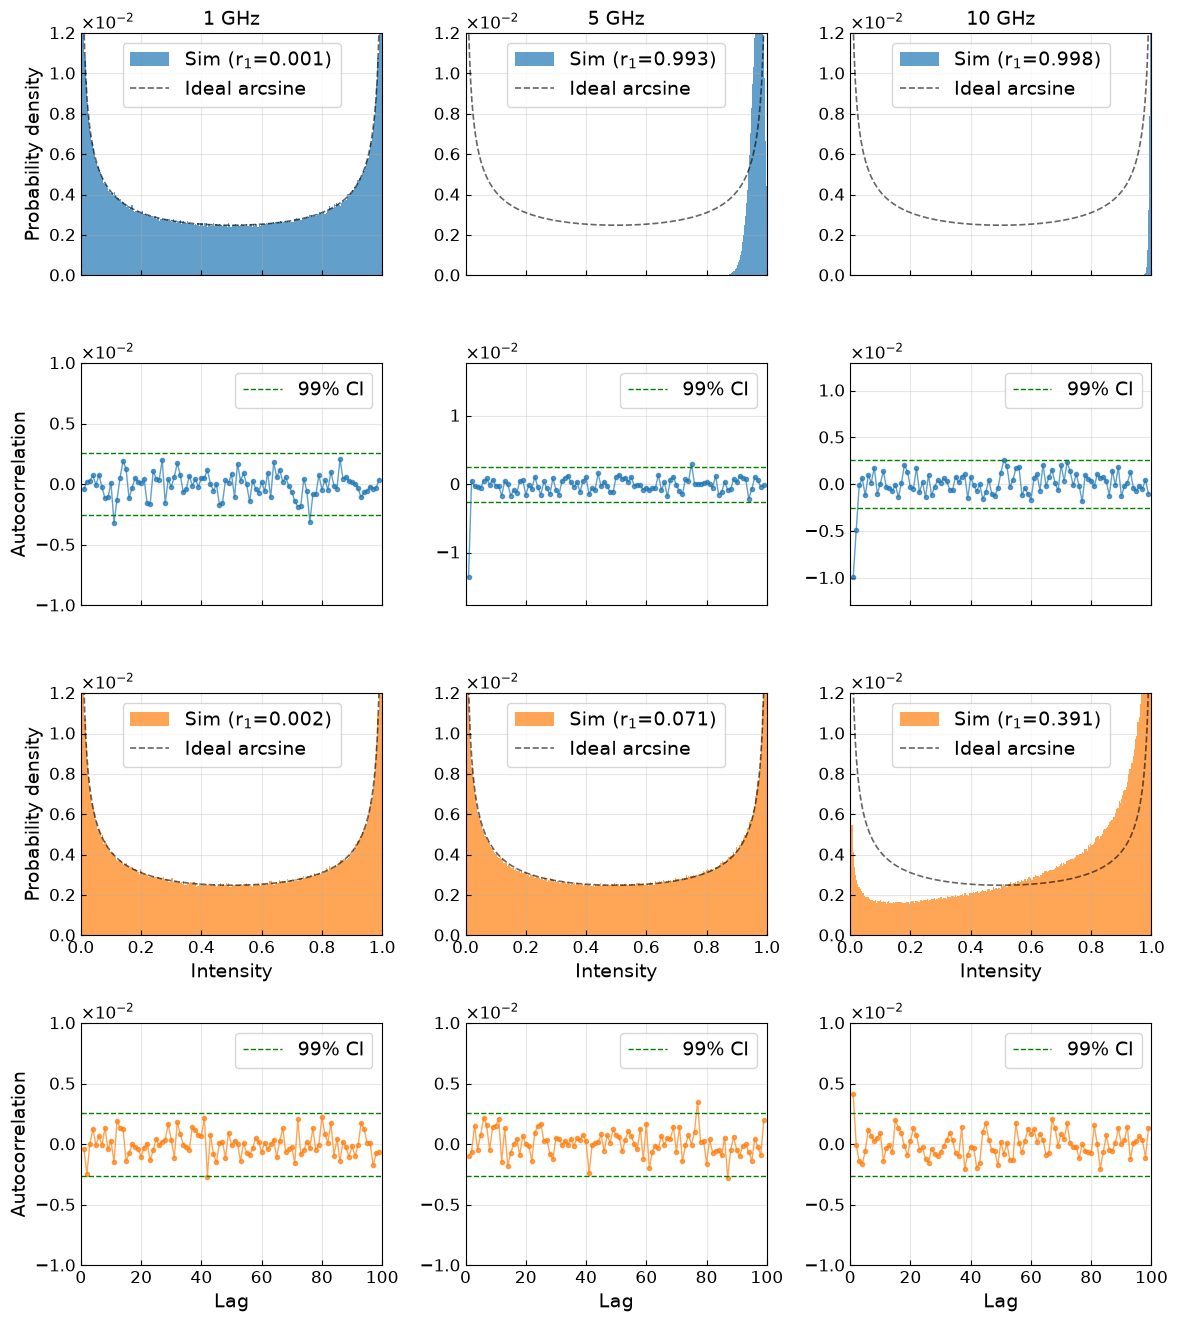

In [109]:
from matplotlib.ticker import ScalarFormatter
fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))

n_freq = 3 # en(freq_labels)
ci99_eta = bartlett_ci(N_PULSES, FIG1_CI_LEVEL)

fig1, axes1 = plt.subplots(
    4, n_freq,
    figsize=(FIG1_FIGSIZE[0] * n_freq, FIG1_FIGSIZE[1] * 4))

# fig1.suptitle(
#     f'AMZI Splitting Ratio: Histograms and Autocorrelation ({N_PULSES//1000}k pulses)\n'
#     f'Rows 1–2: free-running | Rows 3–4: 19 mW SLD injection (BW = {ACCEPTANCE_BW} nm)',
#     fontsize=13, y=0.98)

for col, flabel in enumerate(freq_labels):
    for blk, inj_label in enumerate(['free', 'sld']):
        eta = freq_sweep[f'{flabel}_{inj_label}_eta']
        r1 = scalars[f'{flabel}_{inj_label}']['r1']
        eta_ac = eta_autocorrelation(eta, FIG1_MAX_LAG)

        row_hist = 2 * blk
        row_ac   = 2 * blk + 1

        # Histogram
        ax_h = axes1[row_hist, col]
        color = 'C0' if blk == 0 else 'C1'
        ax_h.hist(eta, bins=FIG1_BINS, weights=np.ones_like(eta)/len(eta), # density=True,
                  alpha=FIG1_HIST_ALPHA, color=color,
                  label=f'Sim (r$_1$={r1:.3f})')
        bin_width = 1.0 / FIG1_BINS  # η range [0,1] divided into 256 bins
        arcsine_scaled = arcsine_pdf * bin_width
        ax_h.plot(eta_th, arcsine_scaled, 'k--', lw=1.2, alpha=0.6,
                  label='Ideal arcsine')
        ax_h.set_xlim(0, 1)
        ax_h.set_ylim(0, FIG1_YLIM_HIST)
        if row_hist == 0:
            ax_h.set_title(flabel, fontsize=14)
        if col == 0:
            tag = 'Free' if blk == 0 else 'SLD'
            ax_h.set_ylabel(f'Probability density')
        ax_h.legend(fontsize=14, loc='upper center')
        ax_h.grid(True, alpha=0.3)
        if row_hist < 2:
            ax_h.set_xticklabels([])
        else:
            ax_h.set_xlabel('Intensity')
        ax_h.tick_params(axis='both', direction='in')
        ax_h.yaxis.set_major_formatter(fmt)
        ax_h.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        
        # Autocorrelation
        ax_a = axes1[row_ac, col]
        lags = np.arange(len(eta_ac))
        # ax_a.bar(lags[1:], eta_ac[1:], width=0.8,
        #          color=color, alpha=0.7)
        ax_a.plot(lags[1:], eta_ac[1:], 'o-', ms=3, lw=1,
          color='C0' if blk == 0 else 'C1', alpha=0.7)
        ax_a.axhline(+ci99_eta, color='g', ls='--', lw=1)
        ax_a.axhline(-ci99_eta, color='g', ls='--', lw=1,
                     label=f'{FIG1_CI_LEVEL*100:.0f}% CI') #= ±{ci99_eta:.4f}')
        ax_a.set_xlim(0, FIG1_MAX_LAG)
        if col == 0:
            tag = 'Free' if blk == 0 else 'SLD'
            ax_a.set_ylabel(f'Autocorrelation')
        ax_a.grid(True, alpha=0.3)
        ymax = max(0.01, 1.3 * np.max(np.abs(eta_ac[1:])))
        ax_a.set_ylim(-min(ymax, 1.0), min(ymax, 1.0))
        if row_ac < 3:
            ax_a.set_xticklabels([])
        else:
            ax_a.set_xlabel('Lag')
        ax_a.legend(fontsize=14, loc='upper right')
        ax_a.tick_params(axis='both', direction='in')
        ax_a.yaxis.set_major_formatter(fmt)
        ax_a.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        
plt.tight_layout(rect=[0, 0, 1, 0.96])
if FIG1_SAVE:
    fig1.savefig(OUT / 'sim_phase_randomisation.png',
                 dpi=FIG1_DPI, bbox_inches='tight')
    print(f'Saved: {OUT}/sim_phase_randomisation.png')
plt.show()

---
## Figure 2 — Phase Autocorrelation (Selected Cases)

In [37]:
# ─── Tweakable parameters ───────────────────────────────────────
FIG2_CASES = [
    ('1 GHz_free',  '1 GHz — Free (reference)'),
    ('10 GHz_free', '10 GHz — Free'),
    ('10 GHz_sld',  '10 GHz — SLD injected'),
]
FIG2_CI_LEVELS   = [0.99, 0.999]
FIG2_MAX_LAG     = 50
FIG2_FIGSIZE     = (18, 5)
FIG2_DPI         = 150
FIG2_SAVE        = False
# ────────────────────────────────────────────────────────────────

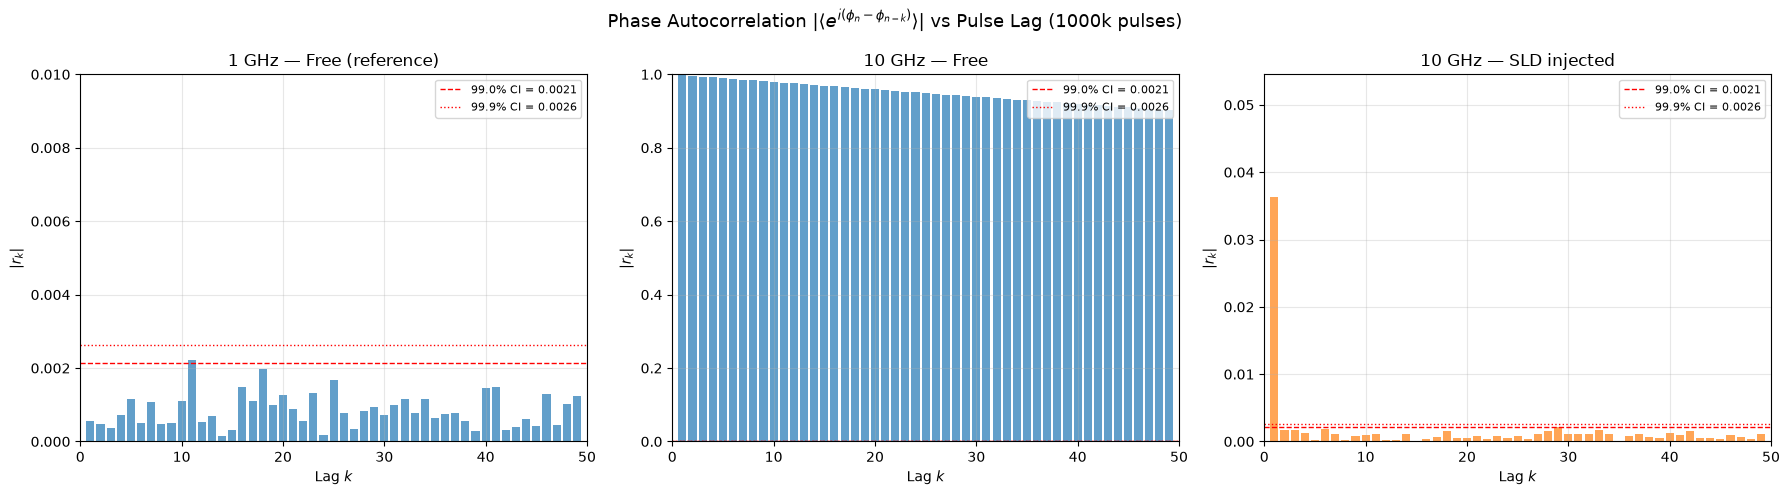

In [38]:
fig2, axes2 = plt.subplots(1, len(FIG2_CASES), figsize=FIG2_FIGSIZE)
fig2.suptitle(
    'Phase Autocorrelation $|\\langle e^{i(\\phi_n - \\phi_{n-k})} \\rangle|$ '
    f'vs Pulse Lag ({N_PULSES//1000}k pulses)', fontsize=13)

ci_vals = {c: autocorr_ci(N_PULSES, c) for c in FIG2_CI_LEVELS}

for ax, (key, title) in zip(axes2, FIG2_CASES):
    ac = freq_sweep[f'{key}_autocorr']
    lags = np.arange(min(len(ac), FIG2_MAX_LAG))
    color = 'C0' if 'free' in key else 'C1'

    ax.bar(lags[1:], ac[1:len(lags)], width=0.8,
           color=color, alpha=0.7)

    styles = ['--', ':']
    for (conf, ci_val), ls in zip(ci_vals.items(), styles):
        ax.axhline(ci_val, color='r', ls=ls, lw=1,
                   label=f'{conf*100:.1f}% CI = {ci_val:.4f}')

    ax.set_xlabel('Lag $k$')
    ax.set_ylabel('$|r_k|$')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, FIG2_MAX_LAG)
    ymax = max(0.01, 1.5 * np.max(ac[1:len(lags)]))
    ax.set_ylim(0, min(ymax, 1.0))

plt.tight_layout()
if FIG2_SAVE:
    fig2.savefig(OUT / 'autocorrelation.png',
                 dpi=FIG2_DPI, bbox_inches='tight')
    print(f'Saved: {OUT}/autocorrelation.png')
plt.show()

---
## Figure 3 — Injection Power Sweep at 10 GHz

In [39]:
# ─── Tweakable parameters ───────────────────────────────────────
FIG3_FIGSIZE      = (18, 10)
FIG3_MARKER_SIZE  = 6
FIG3_LINE_WIDTH   = 2
FIG3_DPI          = 150
FIG3_SAVE         = False

# Experimental jitter values from the paper (for overlay)
PAPER_P_MW     = [0, 5, 19, 24]
PAPER_JITTER   = [4.4, 15.1, 21.9, 28.3]
# ────────────────────────────────────────────────────────────────

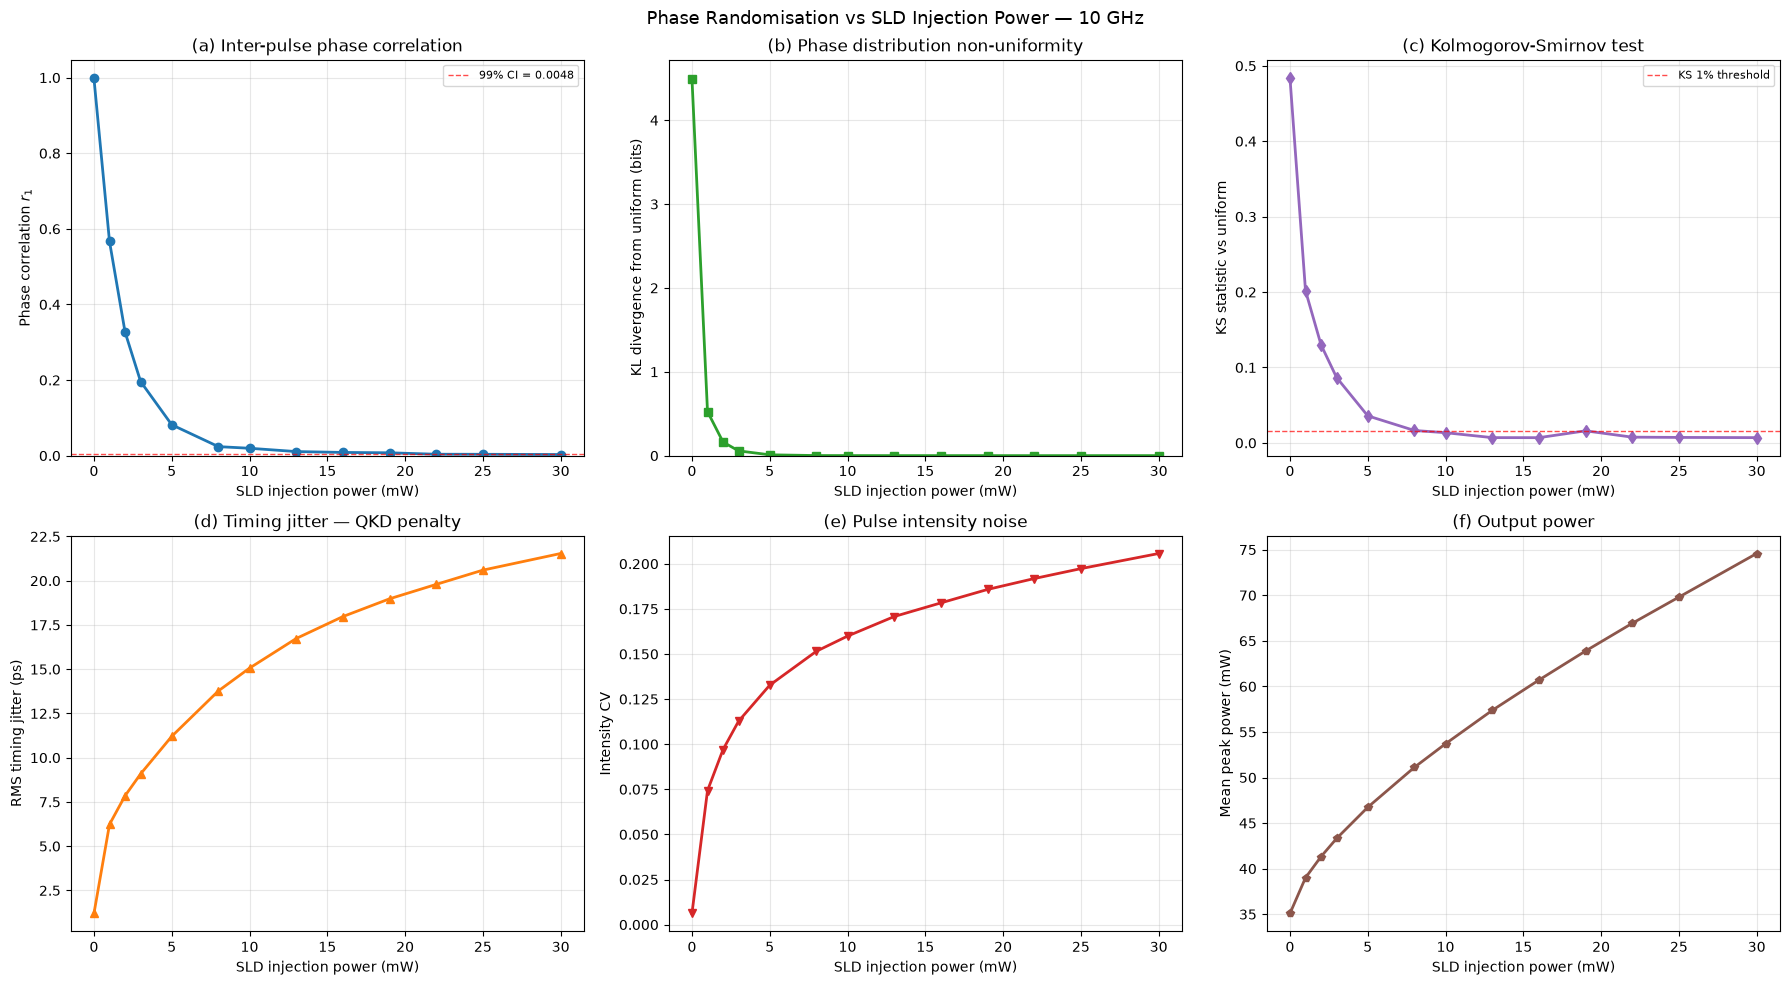

In [40]:
sw = power_sweep
N_sw = params['simulation']['N_pulses_power_sweep']
ci99_sw = autocorr_ci(N_sw, 0.99)

fig3, axes3 = plt.subplots(2, 3, figsize=FIG3_FIGSIZE)
fig3.suptitle(
    'Phase Randomisation vs SLD Injection Power — 10 GHz',
    fontsize=13)

ms = FIG3_MARKER_SIZE
lw = FIG3_LINE_WIDTH

# (a) r1 vs power
ax = axes3[0, 0]
ax.plot(sw['P_mW'], sw['r1'], 'o-', color='C0', lw=lw, ms=ms)
ax.axhline(ci99_sw, color='r', ls='--', lw=1, alpha=0.7,
           label=f'99% CI = {ci99_sw:.4f}')
ax.set_ylabel('Phase correlation $r_1$')
ax.set_title('(a) Inter-pulse phase correlation')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# (b) KL divergence
ax = axes3[0, 1]
ax.plot(sw['P_mW'], sw['kl'], 's-', color='C2', lw=lw, ms=ms)
ax.set_ylabel('KL divergence from uniform (bits)')
ax.set_title('(b) Phase distribution non-uniformity')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# (c) KS statistic
ax = axes3[0, 2]
ax.plot(sw['P_mW'], sw['ks_stat'], 'd-', color='C4', lw=lw, ms=ms)
ax.axhline(1.63 / np.sqrt(min(N_sw, 10000)),
           color='r', ls='--', lw=1, alpha=0.7, label='KS 1% threshold')
ax.set_ylabel('KS statistic vs uniform')
ax.set_title('(c) Kolmogorov-Smirnov test')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (d) Timing jitter
ax = axes3[1, 0]
ax.plot(sw['P_mW'], sw['sigma_t_ps'], '^-', color='C1', lw=lw, ms=ms)
ax.set_ylabel('RMS timing jitter (ps)')
ax.set_title('(d) Timing jitter — QKD penalty')
ax.grid(True, alpha=0.3)

# (e) Intensity CV
ax = axes3[1, 1]
ax.plot(sw['P_mW'], sw['cv_P'], 'v-', color='C3', lw=lw, ms=ms)
ax.set_ylabel('Intensity CV')
ax.set_title('(e) Pulse intensity noise')
ax.grid(True, alpha=0.3)

# (f) Mean power
ax = axes3[1, 2]
ax.plot(sw['P_mW'], sw['mean_P_mW'], 'p-', color='C5', lw=lw, ms=ms)
ax.set_ylabel('Mean peak power (mW)')
ax.set_title('(f) Output power')
ax.grid(True, alpha=0.3)

for ax in axes3.flat:
    ax.set_xlabel('SLD injection power (mW)')

plt.tight_layout()
if FIG3_SAVE:
    fig3.savefig(OUT / 'injection_power_sweep.png',
                 dpi=FIG3_DPI, bbox_inches='tight')
    print(f'Saved: {OUT}/injection_power_sweep.png')
plt.show()

---
## Figure 4 — Optical Spectra

In [41]:
# ─── Tweakable parameters ───────────────────────────────────────
FIG4_FREQ_RANGE_GHZ = 60    # show ± this around carrier
FIG4_YLIM_DB        = (-60, 5)
FIG4_FIGSIZE        = (18, 5)
FIG4_DPI            = 150
FIG4_SAVE           = False

FIG4_CONFIGS = [
    ('1 GHz free',  '1 GHz — Free (reference)', 'C0'),
    ('10 GHz free', '10 GHz — Free (comb lines)', 'C3'),
    ('10 GHz sld',  '10 GHz — SLD injected', 'C1'),
]
# ────────────────────────────────────────────────────────────────

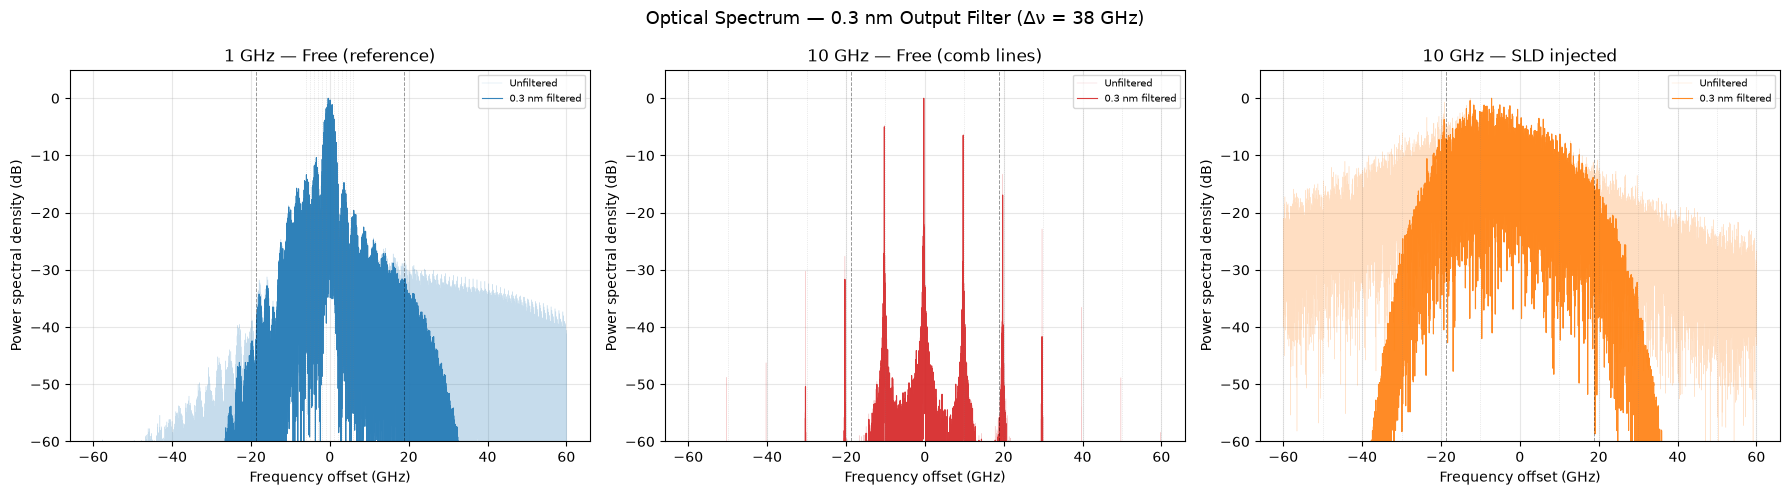

In [42]:
filter_bw_ghz = params['filter']['bw_ghz']
filter_bw_nm  = params['filter']['bw_nm']

fig4, axes4 = plt.subplots(1, len(FIG4_CONFIGS), figsize=FIG4_FIGSIZE)
fig4.suptitle(
    f'Optical Spectrum — {filter_bw_nm} nm Output Filter '
    f'(Δν = {filter_bw_ghz:.0f} GHz)', fontsize=13)

for ax, (key, title, color) in zip(axes4, FIG4_CONFIGS):
    sd = spec_data[key]
    f_GHz = sd['freq_hz'] * 1e-9
    mask = np.abs(f_GHz) < FIG4_FREQ_RANGE_GHZ

    # Unfiltered (faint)
    spec_dB_raw = 10 * np.log10(np.maximum(sd['spectrum_raw'][mask], 1e-10))
    ax.plot(f_GHz[mask], spec_dB_raw, color=color, lw=0.3, alpha=0.25,
            label='Unfiltered')

    # Filtered (bold)
    spec_dB_filt = 10 * np.log10(
        np.maximum(sd['spectrum_filtered'][mask], 1e-10))
    ax.plot(f_GHz[mask], spec_dB_filt, color=color, lw=0.8, alpha=0.9,
            label=f'{filter_bw_nm} nm filtered')

    # Comb line markers
    f_rep_GHz = float(sd['f_rep']) * 1e-9
    for n in range(-6, 7):
        if n != 0:
            ax.axvline(n * f_rep_GHz, color='gray', ls=':', lw=0.5, alpha=0.3)

    # Filter edges
    ax.axvline(-filter_bw_ghz / 2, color='k', ls='--', lw=0.7, alpha=0.4)
    ax.axvline(+filter_bw_ghz / 2, color='k', ls='--', lw=0.7, alpha=0.4)

    ax.set_xlabel('Frequency offset (GHz)')
    ax.set_ylabel('Power spectral density (dB)')
    ax.set_title(title)
    ax.set_ylim(*FIG4_YLIM_DB)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
if FIG4_SAVE:
    fig4.savefig(OUT / 'optical_spectra.png',
                 dpi=FIG4_DPI, bbox_inches='tight')
    print(f'Saved: {OUT}/optical_spectra.png')
plt.show()

---
## Figure 5 — Mechanism Decomposition

In [43]:
# ─── Tweakable parameters ───────────────────────────────────────
FIG5_FIGSIZE    = (18, 5)
FIG5_DPI        = 150
FIG5_SAVE       = False
FIG5_CMAP       = 'viridis'

# Experimental jitter values from paper (for overlay on panel b)
FIG5_PAPER_P       = [0, 5, 19, 24]
FIG5_PAPER_JITTER  = [4.4, 15.1, 21.9, 28.3]
# ────────────────────────────────────────────────────────────────

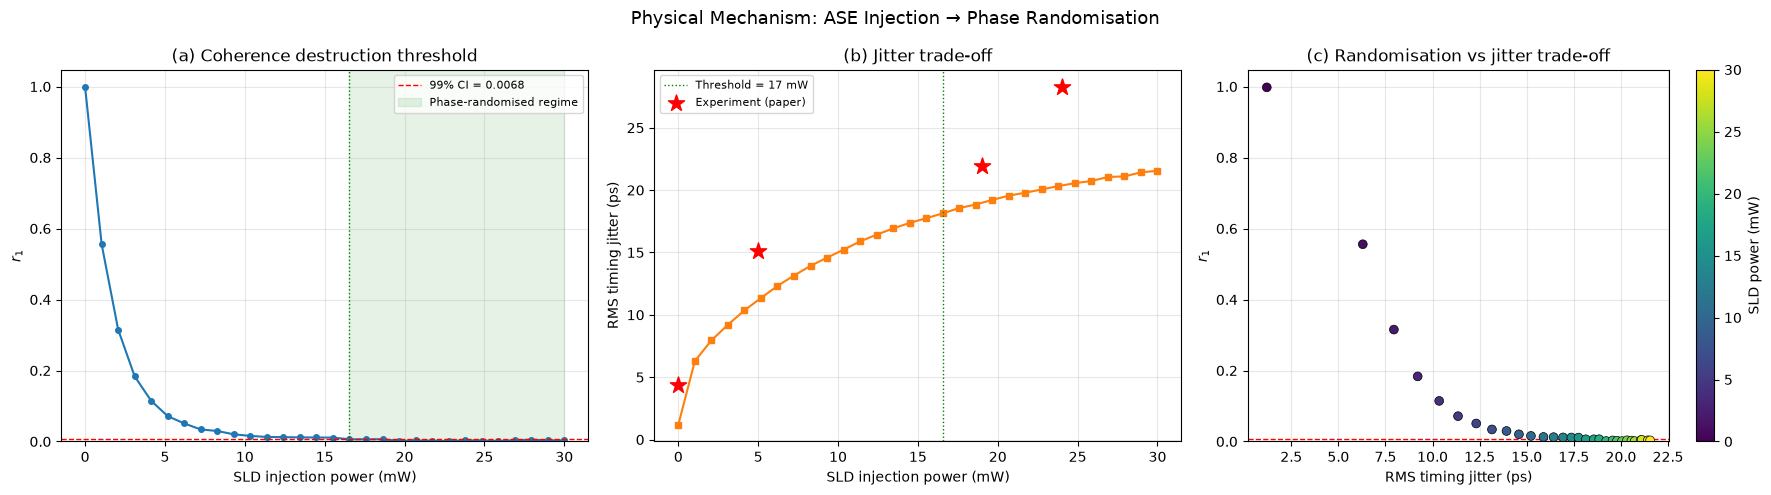

In [44]:
m = mechanism
P_fine = m['P_fine_mW']
r1_fine = m['r1_fine']
jitter_fine = m['jitter_fine_ps']
P_threshold = float(m['P_threshold_mW'])
ci99_mech = float(m['ci99'])

fig5, axes5 = plt.subplots(1, 3, figsize=FIG5_FIGSIZE)
fig5.suptitle(
    'Physical Mechanism: ASE Injection → Phase Randomisation',
    fontsize=13)

# (a) r1 vs SLD power
ax = axes5[0]
ax.plot(P_fine, r1_fine, 'o-', color='C0', ms=4, lw=1.5)
ax.axhline(ci99_mech, color='r', ls='--', lw=1,
           label=f'99% CI = {ci99_mech:.4f}')
ax.axvspan(P_threshold, P_fine[-1], alpha=0.1, color='green',
           label='Phase-randomised regime')
ax.axvline(P_threshold, color='green', ls=':', lw=1)
ax.set_xlabel('SLD injection power (mW)')
ax.set_ylabel('$r_1$')
ax.set_title('(a) Coherence destruction threshold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# (b) jitter vs SLD power
ax = axes5[1]
ax.plot(P_fine, jitter_fine, 's-', color='C1', ms=4, lw=1.5)
ax.axvline(P_threshold, color='green', ls=':', lw=1,
           label=f'Threshold = {P_threshold:.0f} mW')
ax.scatter(FIG5_PAPER_P, FIG5_PAPER_JITTER, marker='*', s=150, c='red',
           zorder=5, label='Experiment (paper)')
ax.set_xlabel('SLD injection power (mW)')
ax.set_ylabel('RMS timing jitter (ps)')
ax.set_title('(b) Jitter trade-off')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (c) r1 vs jitter (parametric)
ax = axes5[2]
sc = ax.scatter(jitter_fine, r1_fine, c=P_fine, cmap=FIG5_CMAP,
                s=40, edgecolors='k', lw=0.5, zorder=3)
ax.axhline(ci99_mech, color='r', ls='--', lw=1)
ax.set_xlabel('RMS timing jitter (ps)')
ax.set_ylabel('$r_1$')
ax.set_title('(c) Randomisation vs jitter trade-off')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('SLD power (mW)')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
if FIG5_SAVE:
    fig5.savefig(OUT / 'mechanism_decomposition.png',
                 dpi=FIG5_DPI, bbox_inches='tight')
    print(f'Saved: {OUT}/mechanism_decomposition.png')
plt.show()

---
## Figure 6 — Detection Chain on AMZI Splitting Ratio

In [45]:
# ─── Tweakable parameters ───────────────────────────────────────
FIG6_BINS       = 200
FIG6_YLIM_HIST  = 12
FIG6_MAX_LAG    = 50
FIG6_FIGSIZE    = (14, 10)
FIG6_DPI        = 150
FIG6_SAVE       = False
# ────────────────────────────────────────────────────────────────

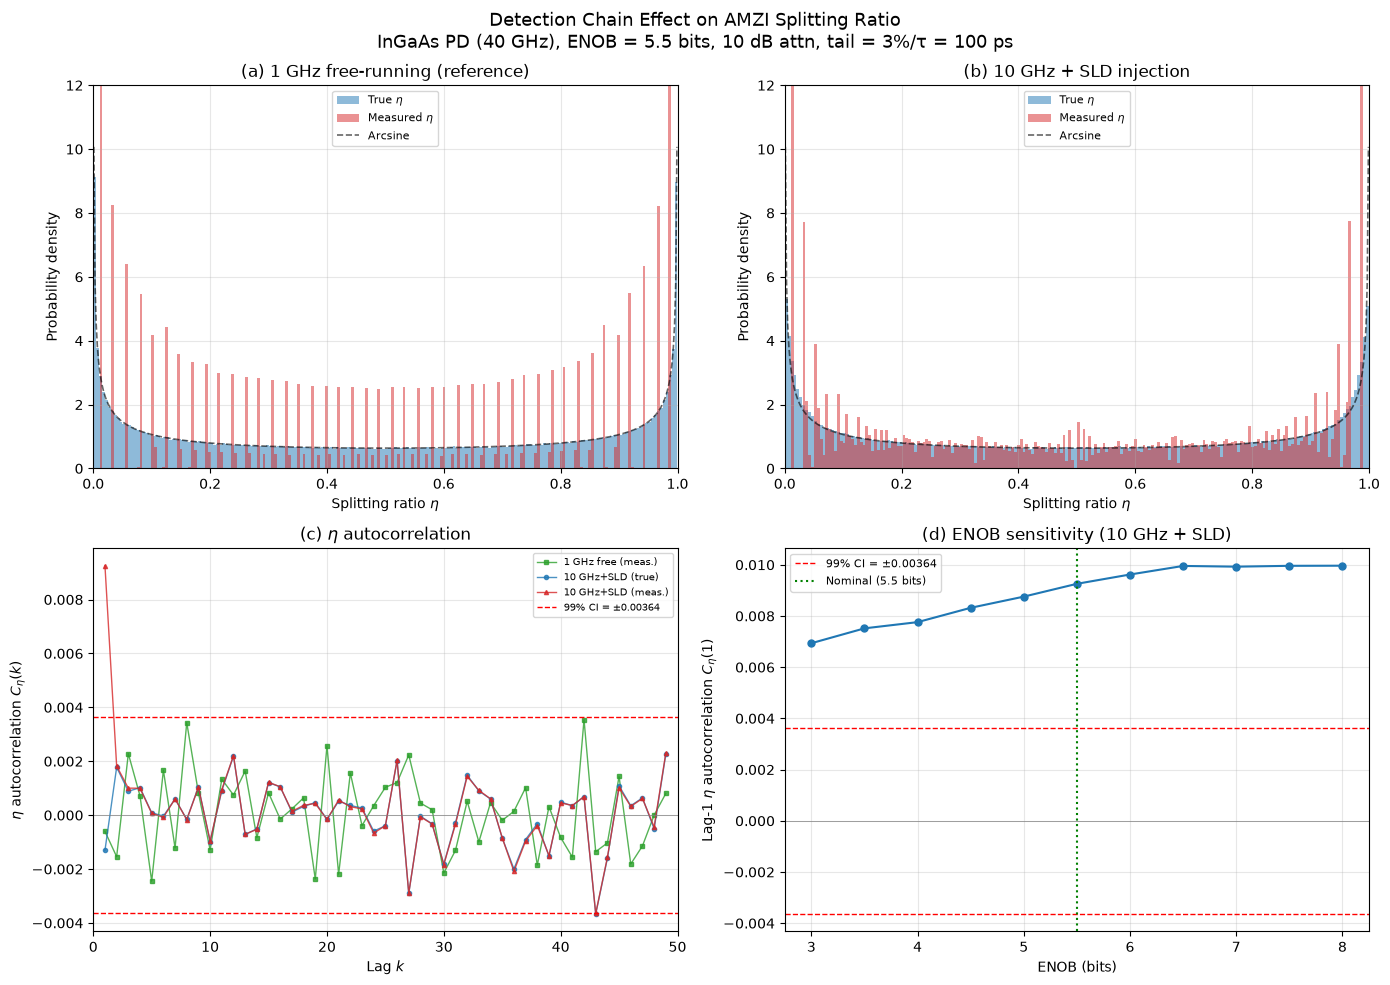

In [46]:
det_p = params['detection']

fig6, axes6 = plt.subplots(2, 2, figsize=FIG6_FIGSIZE)
fig6.suptitle(
    'Detection Chain Effect on AMZI Splitting Ratio\n'
    f'InGaAs PD ({det_p["det_bw_ghz"]:.0f} GHz), '
    f'ENOB = {det_p["scope_enob"]:.1f} bits, '
    f'{det_p["opt_attn_dB"]:.0f} dB attn, '
    f'tail = {det_p["tail_frac"]*100:.0f}%/τ = {det_p["tau_tail_ps"]:.0f} ps',
    fontsize=13)

# (a) η distribution — 1 GHz free
ax = axes6[0, 0]
ax.hist(det_1g['eta_true'], bins=FIG6_BINS, density=True, alpha=0.5,
        color='C0', label='True $\\eta$')
ax.hist(det_1g['eta_meas'], bins=FIG6_BINS, density=True, alpha=0.5,
        color='C3', label='Measured $\\eta$')
ax.plot(eta_th, arcsine_pdf, 'k--', lw=1.2, alpha=0.6, label='Arcsine')
ax.set_xlim(0, 1)
ax.set_ylim(0, FIG6_YLIM_HIST)
ax.set_xlabel('Splitting ratio $\\eta$')
ax.set_ylabel('Probability density')
ax.set_title('(a) 1 GHz free-running (reference)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) η distribution — 10 GHz + SLD
ax = axes6[0, 1]
ax.hist(det_10g['eta_true'], bins=FIG6_BINS, density=True, alpha=0.5,
        color='C0', label='True $\\eta$')
ax.hist(det_10g['eta_meas'], bins=FIG6_BINS, density=True, alpha=0.5,
        color='C3', label='Measured $\\eta$')
ax.plot(eta_th, arcsine_pdf, 'k--', lw=1.2, alpha=0.6, label='Arcsine')
ax.set_xlim(0, 1)
ax.set_ylim(0, FIG6_YLIM_HIST)
ax.set_xlabel('Splitting ratio $\\eta$')
ax.set_ylabel('Probability density')
ax.set_title('(b) 10 GHz + SLD injection')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (c) η autocorrelation
ax = axes6[1, 0]
ci99_det = float(det_10g['ci99'])
lags_d = np.arange(min(len(det_1g['ac_true']), FIG6_MAX_LAG))
ax.plot(lags_d[1:], det_1g['ac_meas'][1:len(lags_d)], 's-', ms=3, lw=1.0,
        color='C2', alpha=0.8, label='1 GHz free (meas.)')
ax.plot(lags_d[1:], det_10g['ac_true'][1:len(lags_d)], 'o-', ms=3, lw=1.0,
        color='C0', alpha=0.8, label='10 GHz+SLD (true)')
ax.plot(lags_d[1:], det_10g['ac_meas'][1:len(lags_d)], '^-', ms=3, lw=1.0,
        color='C3', alpha=0.8, label='10 GHz+SLD (meas.)')
ax.axhline(+ci99_det, color='r', ls='--', lw=1,
           label=f'99% CI = ±{ci99_det:.5f}')
ax.axhline(-ci99_det, color='r', ls='--', lw=1)
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.set_xlabel('Lag $k$')
ax.set_ylabel('$\\eta$ autocorrelation $C_\\eta(k)$')
ax.set_title('(c) $\\eta$ autocorrelation')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, FIG6_MAX_LAG)

# (d) ENOB sensitivity
ax = axes6[1, 1]
ax.plot(det_enob['enob'], det_enob['ac1_vs_enob'], 'o-', ms=5, lw=1.5,
        color='C0')
ax.axhline(+ci99_det, color='r', ls='--', lw=1,
           label=f'99% CI = ±{ci99_det:.5f}')
ax.axhline(-ci99_det, color='r', ls='--', lw=1)
ax.axhline(0, color='gray', ls='-', lw=0.5)
ax.axvline(det_p['scope_enob'], color='green', ls=':', lw=1.5,
           label=f'Nominal ({det_p["scope_enob"]:.1f} bits)')
ax.set_xlabel('ENOB (bits)')
ax.set_ylabel('Lag-1 $\\eta$ autocorrelation $C_\\eta(1)$')
ax.set_title('(d) ENOB sensitivity (10 GHz + SLD)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if FIG6_SAVE:
    fig6.savefig(OUT / 'detection_chain.png',
                 dpi=FIG6_DPI, bbox_inches='tight')
    print(f'Saved: {OUT}/detection_chain.png')
plt.show()

In [126]:
import numpy as np
import json
from pathlib import Path

DATA = Path('../images/acceptance_bw_comparison/data')
bw_list = [0.7, 3.0, 8.0]
freq_labels = ['1 GHz', '2 GHz', '5 GHz', '8 GHz', '10 GHz']

sld = {bw: np.load(DATA / f'sld_bw{bw:.1f}nm.npz', allow_pickle=True) for bw in bw_list}
scalars = {bw: json.loads((DATA / f'scalars_bw{bw:.1f}nm.json').read_text()) for bw in bw_list}

Saved: ../images/acceptance_bw_comparison/acceptance_bw_comparison.png


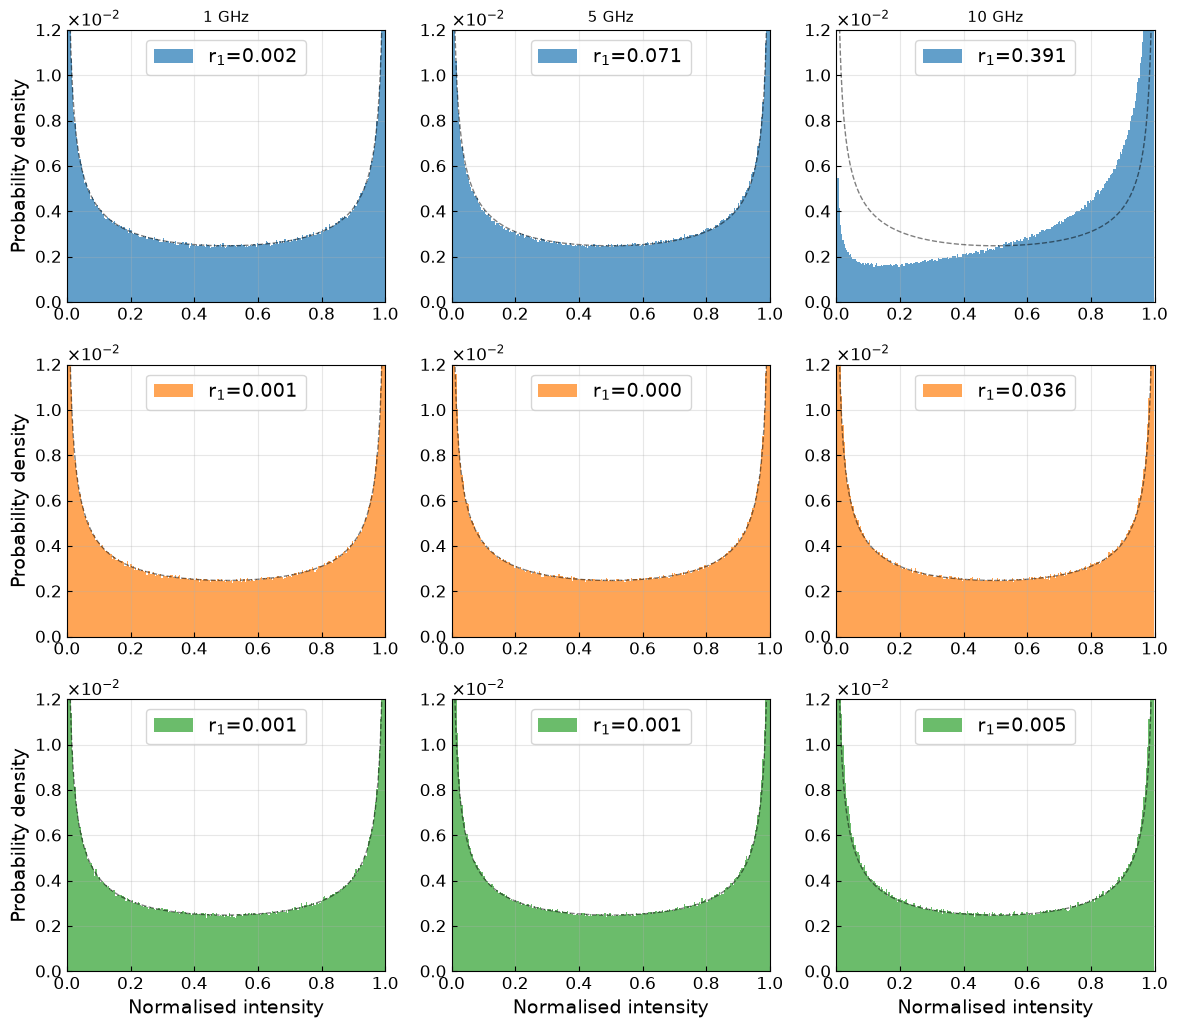

In [143]:
OUT2  = Path('../images/acceptance_bw_comparison')
from matplotlib.ticker import ScalarFormatter
fmt = ScalarFormatter(useMathText=True)
fmt.set_scientific(True)
fmt.set_powerlimits((0, 0))

n_freq = len(freq_labels)
n_bw = len(bw_list)
P_sld_mW = 19.0

fig, axes = plt.subplots(n_bw, n_freq, figsize=(4 * n_freq, 3.5 * n_bw))

eta_th = np.linspace(0.001, 0.999, 500)
arcsine_pdf = 1.0 / (np.pi * np.sqrt(eta_th * (1.0 - eta_th)))

for row, bw_nm in enumerate(bw_list):
    for col, flabel in enumerate(freq_labels):
        ax = axes[row, col]
        eta = sld[bw_nm][f'{flabel}_eta']
        r1 = scalars[bw_nm][f'{flabel}_sld']['r1']
        ax.hist(eta, bins=FIG1_BINS, weights=np.ones_like(eta)/len(eta), # density=True,
                alpha=0.7, color=f'C{row}', label=f'r$_1$={r1:.3f}')
        bin_width = 1.0 / FIG1_BINS  # η range [0,1] divided into 256 bins
        arcsine_scaled = arcsine_pdf * bin_width
        ax.plot(eta_th, arcsine_scaled, 'k--', lw=1, alpha=0.5)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 12e-3)
        if row == 0:
            ax.set_title(flabel, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'Probability density')
        if row == n_bw - 1:
            ax.set_xlabel('Normalised intensity')
        ax.legend(fontsize=14, loc='upper center')
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', direction='in')
        ax.yaxis.set_major_formatter(fmt)
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.tight_layout()
fig.savefig(OUT2 / 'acceptance_bw_comparison.png', dpi=FIG1_DPI, bbox_inches='tight')
print(f'Saved: {OUT2}/acceptance_bw_comparison.png')
plt.show()

---
## Figures 5.8–5.10 — Phase Transition Analysis

Data from `images/phase_transition/phase_transition_data.npz` (1M pulses, λ=1547 nm, L=150 µm, sinusoidal drive).

Frequencies: [1, 2, 5, 8, 10] GHz × 24 injection levels.

In [153]:
# ── Load phase transition data ──────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PT_DATA = Path('../images/phase_transition')
PT_OUT  = PT_DATA

d = np.load(PT_DATA / 'phase_transition_data.npz', allow_pickle=True)

target_freqs = d['target_freqs']          # [1e9, 2e9, 5e9, 8e9, 1e10]
S_inj_values = d['S_inj_values']          # 24 log-spaced values
R1_CRIT      = float(d['R1_CRIT'])        # 1/e
DUTY         = float(d['DUTY'])
N_PT         = int(d['N_PULSES'])

# Fit parameters
beta_fit = float(d['beta_fit'])
beta_err = float(d['beta_err'])
C_fit    = float(d['C_fit'])
a_fit    = float(d['a_fit'])
b_fit    = float(d['b_fit'])
kappa_crit = float(d['kappa_crit'])

def freq_key(f):
    """Convert frequency (Hz) to npz dict key suffix matching _clean().

    _clean(1000000000.0) -> '1000000000p0', so we reproduce that:
    repr(float) then replace '.' with 'p'.
    """
    return repr(float(f)).replace('.', 'p').replace('-', 'm').replace('+', '')

# Per-frequency S_c and colours
S_c = {}
freq_colors_pt = {}
for f in target_freqs:
    fk = freq_key(f)
    S_c[f] = float(d[f'S_c.{fk}'])
    freq_colors_pt[f] = str(d[f'freq_colors.{fk}'])

# Per-frequency, per-injection-level results
n_sinj = len(S_inj_values)
results_pt = {}
for f in target_freqs:
    fk = freq_key(f)
    res_list = []
    for i in range(n_sinj):
        res_list.append({
            'S_inj': float(d[f'results.{fk}.{i}.S_inj']),
            'r1':    float(d[f'results.{fk}.{i}.r1']),
        })
    results_pt[f] = res_list

# Theory curves and scaling arrays
kappa_theory = d['kappa_theory']
r1_theory    = d['r1_theory']
kappa_plot   = d['kappa_plot']
f_arr        = d['f_arr']
Sc_arr       = d['Sc_arr']
ratio_arr    = d['ratio_arr']
ratio_fit    = d['ratio_fit']
Sc_fit       = d['Sc_fit']
f_dense      = d['f_dense']
Sc_dense     = d['Sc_dense']

print(f'Phase transition data loaded: {len(target_freqs)} frequencies, '
      f'{n_sinj} injection levels, {N_PT//1000}k pulses')
print(f'S_c = ' + ', '.join(f'{f*1e-9:.0f} GHz: {S_c[f]:.2e}' for f in target_freqs))
print(f'beta = {beta_fit:.3f} +/- {beta_err:.3f}, b = {b_fit:.4f}')

Phase transition data loaded: 5 frequencies, 24 injection levels, 1000k pulses
S_c = 1 GHz: 1.00e+22, 2 GHz: 1.00e+22, 5 GHz: 1.72e+19, 8 GHz: 4.20e+19, 10 GHz: 5.77e+19
beta = 0.500 +/- 0.000, b = 0.0425


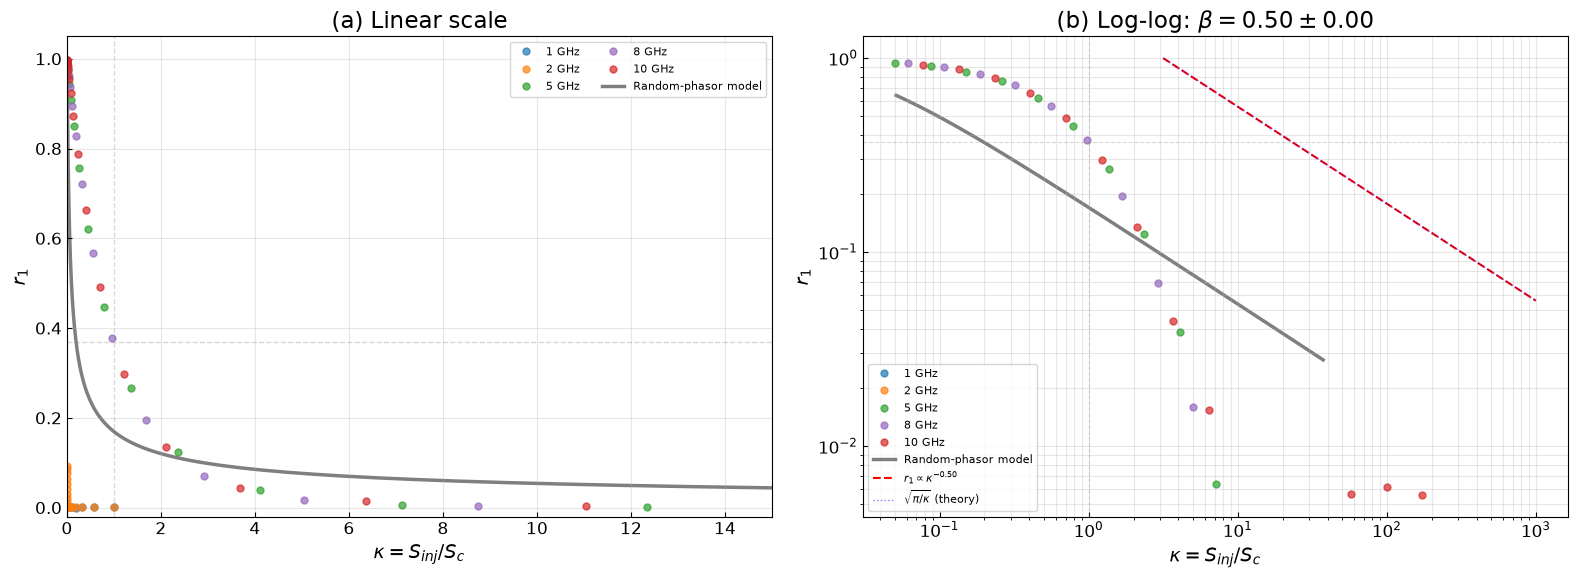

In [154]:
# ─── Fig 5.8: Universal data collapse — Tweakable ─────────────
FIG8_FIGSIZE   = (16, 6)
FIG8_MS        = 5
FIG8_XLIM_LIN  = (0, 15)
FIG8_DPI       = 150
FIG8_SAVE      = False
# ───────────────────────────────────────────────────────────────

fig8, axes8 = plt.subplots(1, 2, figsize=FIG8_FIGSIZE)

# (a) Linear scale
ax = axes8[0]
for f_rep in target_freqs:
    fg = f_rep * 1e-9
    res = results_pt[f_rep]
    s_c = S_c[f_rep]
    kappa = [r['S_inj'] / s_c for r in res]
    r1 = [r['r1'] for r in res]
    col = freq_colors_pt[f_rep]
    ax.plot(kappa, r1, 'o', color=col, ms=FIG8_MS, alpha=0.7,
            label=f'{fg:.0f} GHz')

kp = kappa_plot / kappa_crit
ax.plot(kp, r1_theory, 'k-', lw=2.5, alpha=0.5,
        label='Random-phasor model', zorder=0)
ax.axhline(R1_CRIT, color='gray', ls='--', lw=1, alpha=0.3)
ax.axvline(1.0, color='gray', ls='--', lw=1, alpha=0.3)
ax.set_xlabel('$\\kappa = S_{inj} / S_c$')
ax.set_ylabel('$r_1$')
ax.set_title('(a) Linear scale')
ax.set_xlim(*FIG8_XLIM_LIN)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

# (b) Log-log scale
ax = axes8[1]
for f_rep in target_freqs:
    fg = f_rep * 1e-9
    res = results_pt[f_rep]
    s_c = S_c[f_rep]
    kappa = np.array([r['S_inj'] / s_c for r in res])
    r1 = np.array([r['r1'] for r in res])
    mask = (kappa > 0.05) & (r1 > 0.005)
    col = freq_colors_pt[f_rep]
    ax.loglog(kappa[mask], r1[mask], 'o', color=col, ms=FIG8_MS, alpha=0.7,
              label=f'{fg:.0f} GHz')

mask_th = (kp > 0.05) & (r1_theory > 0.005)
ax.loglog(kp[mask_th], r1_theory[mask_th], 'k-', lw=2.5,
          alpha=0.5, label='Random-phasor model', zorder=0)
kappa_ref = np.logspace(0.5, 3, 50)
ax.loglog(kappa_ref, C_fit * kappa_ref**(-beta_fit), 'r--', lw=1.5,
          label=f'$r_1 \\propto \\kappa^{{-{beta_fit:.2f}}}$')
ax.loglog(kappa_ref, np.sqrt(np.pi) * kappa_ref**(-0.5), 'b:', lw=1,
          alpha=0.5, label='$\\sqrt{\\pi/\\kappa}$ (theory)')
ax.axhline(R1_CRIT, color='gray', ls='--', lw=0.8, alpha=0.3)
ax.axvline(1.0, color='gray', ls='--', lw=0.8, alpha=0.3)
ax.set_xlabel('$\\kappa = S_{inj} / S_c$')
ax.set_ylabel('$r_1$')
ax.set_title(f'(b) Log-log: $\\beta = {beta_fit:.2f} \\pm {beta_err:.2f}$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.tick_params(axis='both', direction='in')

plt.tight_layout()
if FIG8_SAVE:
    fig8.savefig(PT_OUT / 'universal_collapse.png', dpi=FIG8_DPI, bbox_inches='tight')
    print(f'Saved: {PT_OUT}/universal_collapse.png')
plt.show()

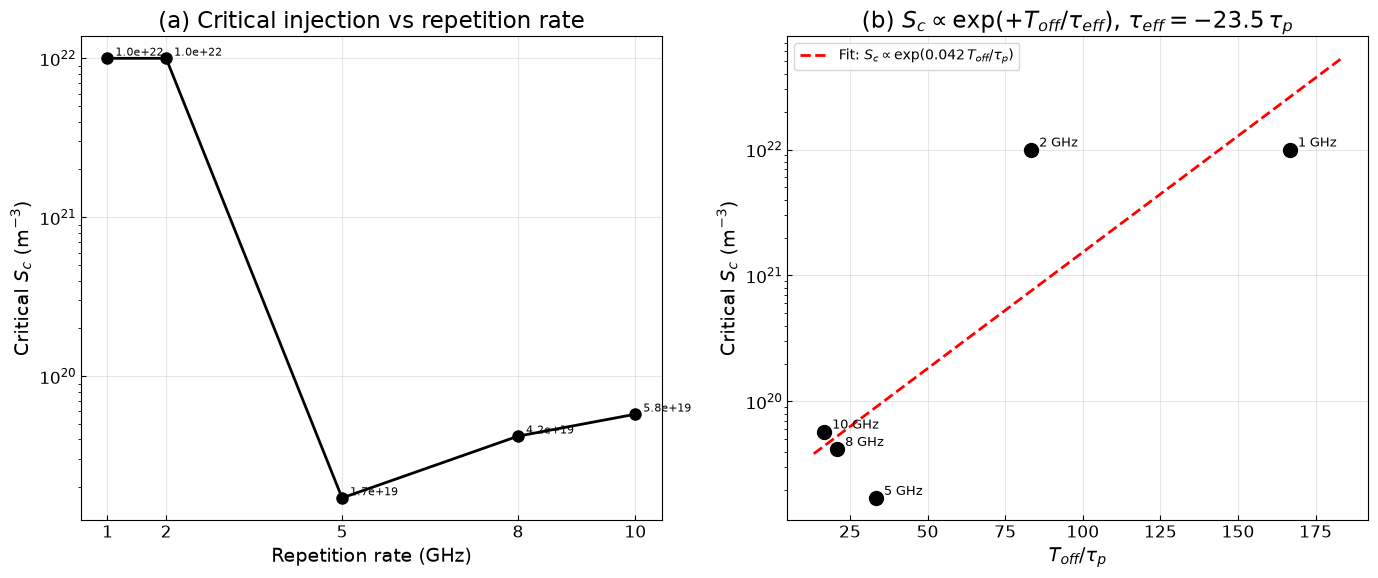

In [155]:
# ─── Fig 5.9: S_c scaling with frequency — Tweakable ──────────
FIG9_FIGSIZE = (14, 6)
FIG9_MS      = 8
FIG9_DPI     = 150
FIG9_SAVE    = False
# ───────────────────────────────────────────────────────────────

tau_eff_ratio = -1 / b_fit

fig9, axes9 = plt.subplots(1, 2, figsize=FIG9_FIGSIZE)

# (a) S_c vs frequency
ax = axes9[0]
ax.semilogy(f_arr, Sc_arr, 'ko-', lw=2, ms=FIG9_MS)
for i, fg in enumerate(f_arr):
    ax.annotate(f'  {Sc_arr[i]:.1e}', (fg, Sc_arr[i]),
                fontsize=8, va='bottom')
ax.set_xlabel('Repetition rate (GHz)')
ax.set_ylabel('Critical $S_c$ (m$^{-3}$)')
ax.set_title('(a) Critical injection vs repetition rate')
ax.set_xticks(f_arr)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

# (b) S_c vs T_off/tau_p
ax = axes9[1]
ax.semilogy(ratio_arr, Sc_arr, 'ko', ms=FIG9_MS + 2, zorder=5)
ax.semilogy(ratio_fit, Sc_fit, 'r--', lw=2,
            label=f'Fit: $S_c \\propto \\exp({b_fit:.3f}\\, T_{{off}}/\\tau_p)$')
for i, fg in enumerate(f_arr):
    ax.annotate(f'  {fg:.0f} GHz', (ratio_arr[i], Sc_arr[i]),
                fontsize=9, va='bottom')
ax.set_xlabel('$T_{off} / \\tau_p$')
ax.set_ylabel('Critical $S_c$ (m$^{-3}$)')
ax.set_title(
    f'(b) $S_c \\propto \\exp(+T_{{off}}/\\tau_{{eff}})$, '
    f'$\\tau_{{eff}} = {tau_eff_ratio:.1f}\\,\\tau_p$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

plt.tight_layout()
if FIG9_SAVE:
    fig9.savefig(PT_OUT / 'Sc_scaling.png', dpi=FIG9_DPI, bbox_inches='tight')
    print(f'Saved: {PT_OUT}/Sc_scaling.png')
plt.show()

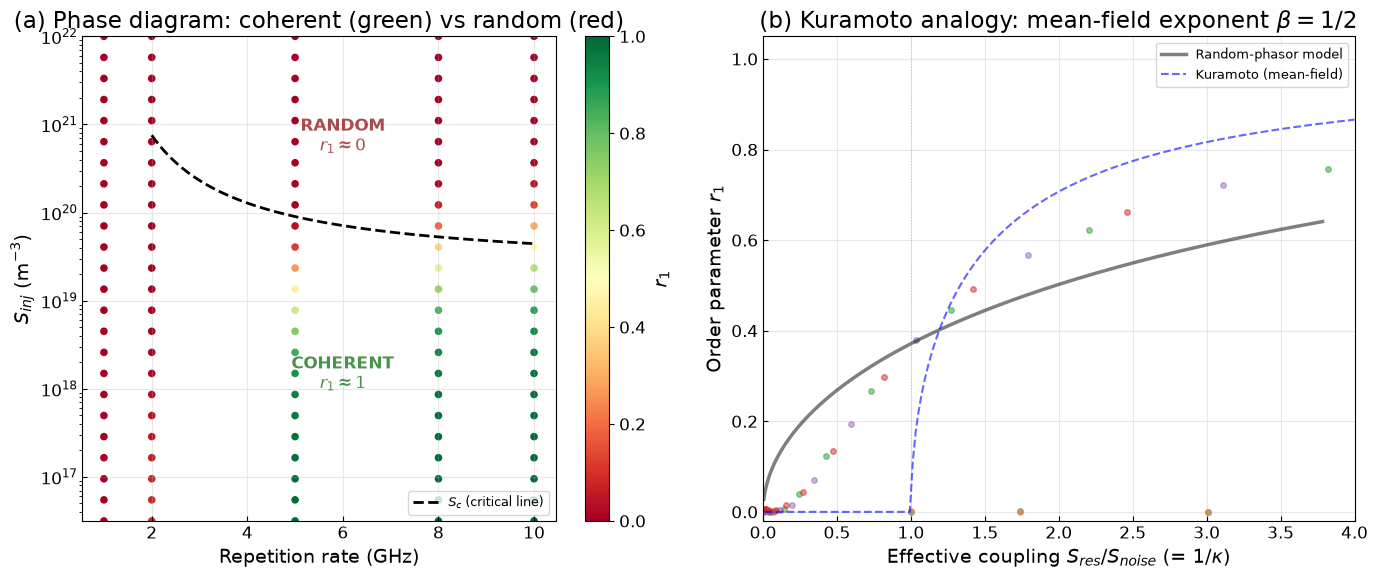

In [156]:
# ─── Fig 5.10: Phase diagram + Kuramoto analogy — Tweakable ───
FIG10_FIGSIZE = (14, 6)
FIG10_MS      = 4
FIG10_DPI     = 150
FIG10_SAVE    = False
# ───────────────────────────────────────────────────────────────

fig10, axes10 = plt.subplots(1, 2, figsize=FIG10_FIGSIZE)

# (a) 2D phase diagram: f_rep vs S_inj, colour = r1
ax = axes10[0]
f_grid, s_grid, r1_grid = [], [], []
for f_rep in target_freqs:
    for r in results_pt[f_rep]:
        f_grid.append(f_rep * 1e-9)
        s_grid.append(r['S_inj'])
        r1_grid.append(r['r1'])

sc = ax.scatter(f_grid, s_grid, c=r1_grid, cmap='RdYlGn',
                s=30, vmin=0, vmax=1, edgecolors='none')
plt.colorbar(sc, ax=ax, label='$r_1$')

ax.plot(f_dense, Sc_dense, 'k--', lw=2, label='$S_c$ (critical line)')
ax.set_yscale('log')
ax.set_xlabel('Repetition rate (GHz)')
ax.set_ylabel('$S_{inj}$ (m$^{-3}$)')
ax.set_title('(a) Phase diagram: coherent (green) vs random (red)')
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(S_inj_values[0], S_inj_values[-1])
ax.text(6, 1e18, 'COHERENT\n$r_1 \\approx 1$',
        fontsize=12, ha='center', color='darkgreen', alpha=0.7,
        fontweight='bold')
ax.text(6, 5e20, 'RANDOM\n$r_1 \\approx 0$',
        fontsize=12, ha='center', color='darkred', alpha=0.7,
        fontweight='bold')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

# (b) Kuramoto analogy
ax = axes10[1]
for f_rep in target_freqs:
    fg = f_rep * 1e-9
    res = results_pt[f_rep]
    s_c = S_c[f_rep]
    inv_kappa = np.array([s_c / r['S_inj'] for r in res])
    r1 = np.array([r['r1'] for r in res])
    col = freq_colors_pt[f_rep]
    ax.plot(inv_kappa, r1, 'o', color=col, ms=FIG10_MS, alpha=0.5)

inv_kappa_th = kappa_crit / kappa_theory
mask_p = inv_kappa_th < 4
ax.plot(inv_kappa_th[mask_p], r1_theory[mask_p], 'k-', lw=2.5, alpha=0.5,
        label='Random-phasor model')

K_kur = np.linspace(0.01, 4, 200)
r_kur = np.where(K_kur > 1.0,
                 np.sqrt(np.maximum(1 - 1.0 / K_kur, 0)), 0)
ax.plot(K_kur, r_kur, 'b--', lw=1.5, alpha=0.6,
        label='Kuramoto (mean-field)')

ax.axvline(1.0, color='gray', ls=':', lw=0.8, alpha=0.3)
ax.set_xlabel('Effective coupling $S_{res} / S_{noise}$ (= $1/\\kappa$)')
ax.set_ylabel('Order parameter $r_1$')
ax.set_title('(b) Kuramoto analogy: mean-field exponent $\\beta = 1/2$')
ax.legend(fontsize=9)
ax.set_xlim(0, 4)
ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

plt.tight_layout()
if FIG10_SAVE:
    fig10.savefig(PT_OUT / 'phase_diagram.png', dpi=FIG10_DPI, bbox_inches='tight')
    print(f'Saved: {PT_OUT}/phase_diagram.png')
plt.show()

---
## Figures — Timing Jitter Analysis

Data from `images/timing_jitter/timing_jitter_data.npz` (1M pulses, sinusoidal drive, 1–10 GHz).

Figures:
- **Jitter vs frequency** — absolute, period, and phase jitter (free vs SLD)
- **Arrival distributions** — peak arrival time histograms at selected frequencies
- **Jitter trade-off** — timing vs phase jitter parametric plot + SLD ratio
- **Correlations at 10 GHz** — *requires raw per-pulse data; run script directly*
- **Allan deviation** — timing stability at selected frequencies

In [157]:
# ── Load timing jitter data ─────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

TJ_DATA = Path('../images/timing_jitter')
TJ_OUT  = TJ_DATA

tj = np.load(TJ_DATA / 'timing_jitter_data.npz', allow_pickle=True)

tj_freqs = tj['freqs']            # [1e9, 2e9, ..., 1e10]
tj_f_ghz = tj['f_ghz']            # [1, 2, ..., 10]
tj_N     = int(tj['N_PULSES'])
tj_DUTY  = float(tj['DUTY'])
tj_I_DC  = float(tj['I_DC'])
tj_V_RF  = float(tj['V_RF_AMP'])
tj_S_INJ = float(tj['S_INJ'])

# Unpack per-frequency, per-case scalar metrics into convenient dicts
tj_data = {}
for fg in tj_f_ghz:
    for case in ['free', 'sld']:
        key = f'{fg:.0f}GHz_{case}'
        tj_data[key] = {
            'sig_t':   float(tj[f'data.{key}.sig_t']),
            'sig_T':   float(tj[f'data.{key}.sig_T']),
            'sig_phi': float(tj[f'data.{key}.sig_phi']),
            'r1':      float(tj[f'data.{key}.r1']),
            'f_rep':   float(tj[f'data.{key}.f_rep']),
            'T_rep':   float(tj[f'data.{key}.T_rep']),
        }
        # Arrival time histogram (t_peak was > 200k so stored as histogram)
        tj_data[key]['t_peak_counts'] = tj[f'data.{key}.t_peak__hist_counts']
        tj_data[key]['t_peak_edges']  = tj[f'data.{key}.t_peak__hist_edges']
        tj_data[key]['t_peak_stats']  = tj[f'data.{key}.t_peak__stats']
        # Allan deviation (small arrays, stored directly)
        tj_data[key]['tau_ad'] = tj[f'data.{key}.tau_ad']
        tj_data[key]['adev']   = tj[f'data.{key}.adev']

print(f'Timing jitter data loaded: {len(tj_f_ghz)} frequencies, '
      f'{tj_N//1000}k pulses')
print(f'I_DC={tj_I_DC*1e3:.1f} mA, V_RF={tj_V_RF} V, '
      f'S_inj={tj_S_INJ:.2e} m^-3, duty={tj_DUTY:.2f}')
print(f'Jitter @ 10 GHz: free={tj_data["10GHz_free"]["sig_t"]*1e12:.2f} ps, '
      f'sld={tj_data["10GHz_sld"]["sig_t"]*1e12:.2f} ps')

Timing jitter data loaded: 10 frequencies, 1000k pulses
I_DC=45.5 mA, V_RF=3.7 V, S_inj=6.17e+20 m^-3, duty=0.66
Jitter @ 10 GHz: free=1.20 ps, sld=18.98 ps


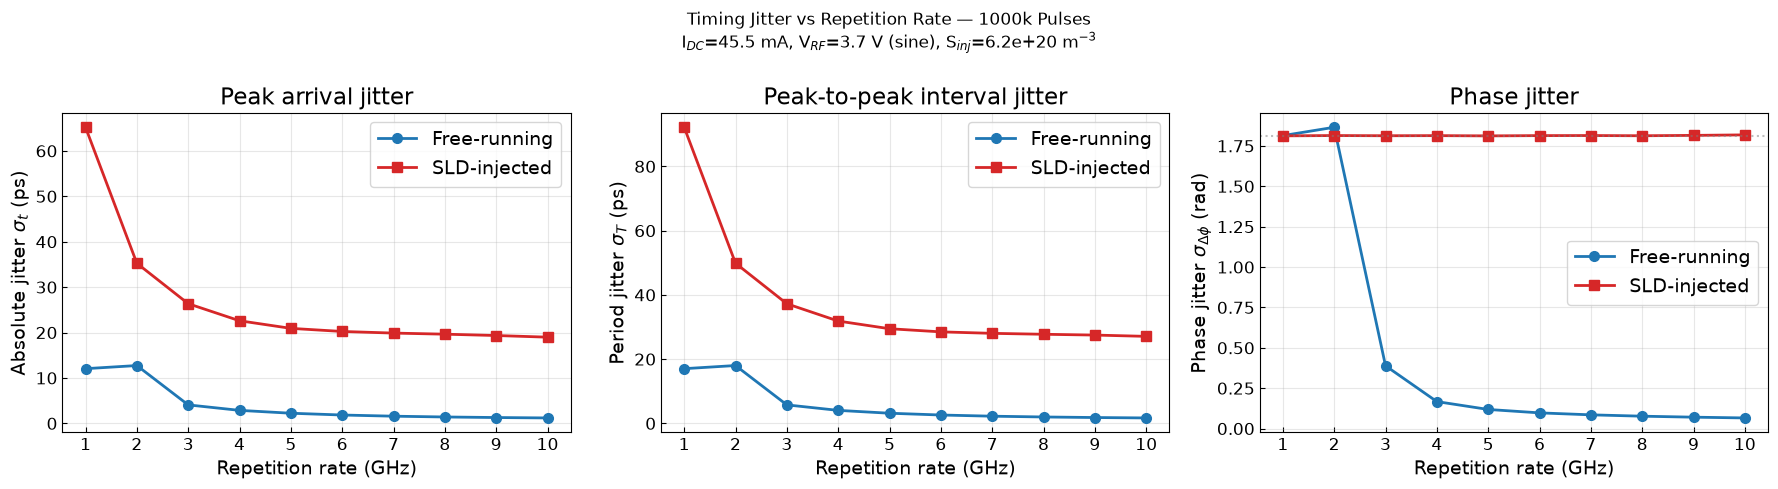

In [158]:
# ─── Jitter vs frequency — Tweakable ───────────────────────────
TJ1_FIGSIZE = (18, 5)
TJ1_MS      = 7
TJ1_LW      = 2
TJ1_DPI     = 150
TJ1_SAVE    = False
# ───────────────────────────────────────────────────────────────

fig_tj1, axes_tj1 = plt.subplots(1, 3, figsize=TJ1_FIGSIZE)
fig_tj1.suptitle(
    f'Timing Jitter vs Repetition Rate — {tj_N//1000}k Pulses\n'
    f'I$_{{DC}}$={tj_I_DC*1e3:.1f} mA, '
    f'V$_{{RF}}$={tj_V_RF} V (sine), '
    f'S$_{{inj}}$={tj_S_INJ:.1e} m$^{{-3}}$',
    fontsize=12)

for case, color, marker, label in [
    ('free', 'C0', 'o', 'Free-running'),
    ('sld', 'C3', 's', 'SLD-injected'),
]:
    sig_t_vals = [tj_data[f"{f:.0f}GHz_{case}"]['sig_t'] * 1e12
                  for f in tj_f_ghz]
    sig_T_vals = [tj_data[f"{f:.0f}GHz_{case}"]['sig_T'] * 1e12
                  for f in tj_f_ghz]
    sig_phi_vals = [tj_data[f"{f:.0f}GHz_{case}"]['sig_phi']
                    for f in tj_f_ghz]

    axes_tj1[0].plot(tj_f_ghz, sig_t_vals, f'{marker}-', color=color,
                     lw=TJ1_LW, ms=TJ1_MS, label=label)
    axes_tj1[1].plot(tj_f_ghz, sig_T_vals, f'{marker}-', color=color,
                     lw=TJ1_LW, ms=TJ1_MS, label=label)
    axes_tj1[2].plot(tj_f_ghz, sig_phi_vals, f'{marker}-', color=color,
                     lw=TJ1_LW, ms=TJ1_MS, label=label)

axes_tj1[0].set_ylabel('Absolute jitter $\\sigma_t$ (ps)')
axes_tj1[0].set_title('Peak arrival jitter')
axes_tj1[1].set_ylabel('Period jitter $\\sigma_T$ (ps)')
axes_tj1[1].set_title('Peak-to-peak interval jitter')
axes_tj1[2].set_ylabel('Phase jitter $\\sigma_{\\Delta\\phi}$ (rad)')
axes_tj1[2].set_title('Phase jitter')
axes_tj1[2].axhline(np.pi / np.sqrt(3), color='gray', ls=':', alpha=0.5)

for ax in axes_tj1:
    ax.set_xlabel('Repetition rate (GHz)')
    ax.set_xticks(tj_f_ghz)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', direction='in')

plt.tight_layout()
if TJ1_SAVE:
    fig_tj1.savefig(TJ_OUT / 'jitter_vs_freq.png', dpi=TJ1_DPI, bbox_inches='tight')
    print(f'Saved: {TJ_OUT}/jitter_vs_freq.png')
plt.show()

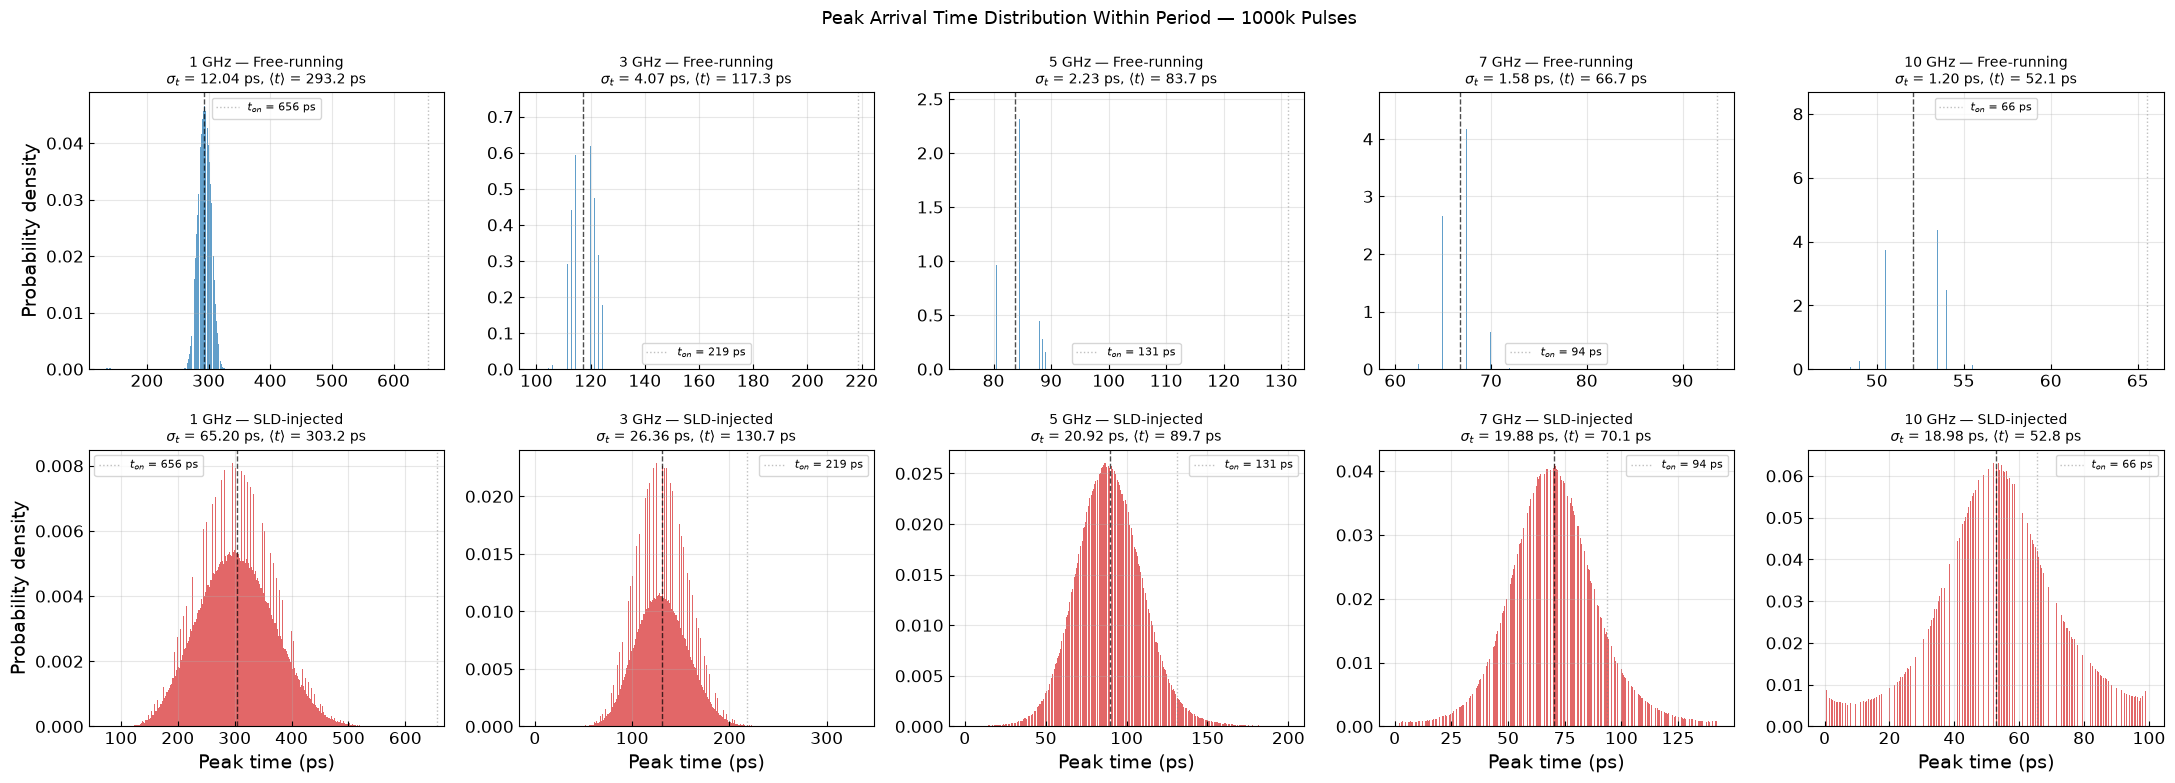

In [159]:
# ─── Arrival distributions — Tweakable ─────────────────────────
TJ2_SEL_GHZ = [1, 3, 5, 7, 10]   # frequencies to show
TJ2_FIGSIZE = (22, 8)
TJ2_DPI     = 150
TJ2_SAVE    = False
# ───────────────────────────────────────────────────────────────

fig_tj2, axes_tj2 = plt.subplots(2, len(TJ2_SEL_GHZ), figsize=TJ2_FIGSIZE)
fig_tj2.suptitle(
    f'Peak Arrival Time Distribution Within Period — {tj_N//1000}k Pulses',
    fontsize=13)

for col, fg in enumerate(TJ2_SEL_GHZ):
    for row, (case, color, label) in enumerate([
        ('free', 'C0', 'Free-running'),
        ('sld', 'C3', 'SLD-injected'),
    ]):
        key = f"{fg}GHz_{case}"
        d = tj_data[key]
        counts = d['t_peak_counts']
        edges  = d['t_peak_edges']
        stats  = d['t_peak_stats']   # [mean, std, min, max, N]
        mean_ps = stats[0] * 1e12
        t_on_ps = tj_DUTY * d['T_rep'] * 1e12

        centres_ps = 0.5 * (edges[:-1] + edges[1:]) * 1e12
        widths_ps  = np.diff(edges) * 1e12
        density = counts / (counts.sum() * widths_ps)

        ax = axes_tj2[row, col]
        ax.bar(centres_ps, density, width=widths_ps, color=color,
               alpha=0.7, edgecolor='none')
        ax.axvline(mean_ps, color='k', ls='--', lw=1, alpha=0.7)
        ax.axvline(t_on_ps, color='gray', ls=':', lw=1, alpha=0.5,
                   label=f'$t_{{on}}$ = {t_on_ps:.0f} ps')
        ax.set_title(
            f'{fg} GHz — {label}\n'
            f'$\\sigma_t$ = {d["sig_t"]*1e12:.2f} ps, '
            f'$\\langle t \\rangle$ = {mean_ps:.1f} ps',
            fontsize=10)
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel('Probability density')
        ax.legend(fontsize=8)
        ax.tick_params(axis='both', direction='in')

    axes_tj2[1, col].set_xlabel('Peak time (ps)')

plt.tight_layout()
if TJ2_SAVE:
    fig_tj2.savefig(TJ_OUT / 'arrival_distributions.png', dpi=TJ2_DPI, bbox_inches='tight')
    print(f'Saved: {TJ_OUT}/arrival_distributions.png')
plt.show()

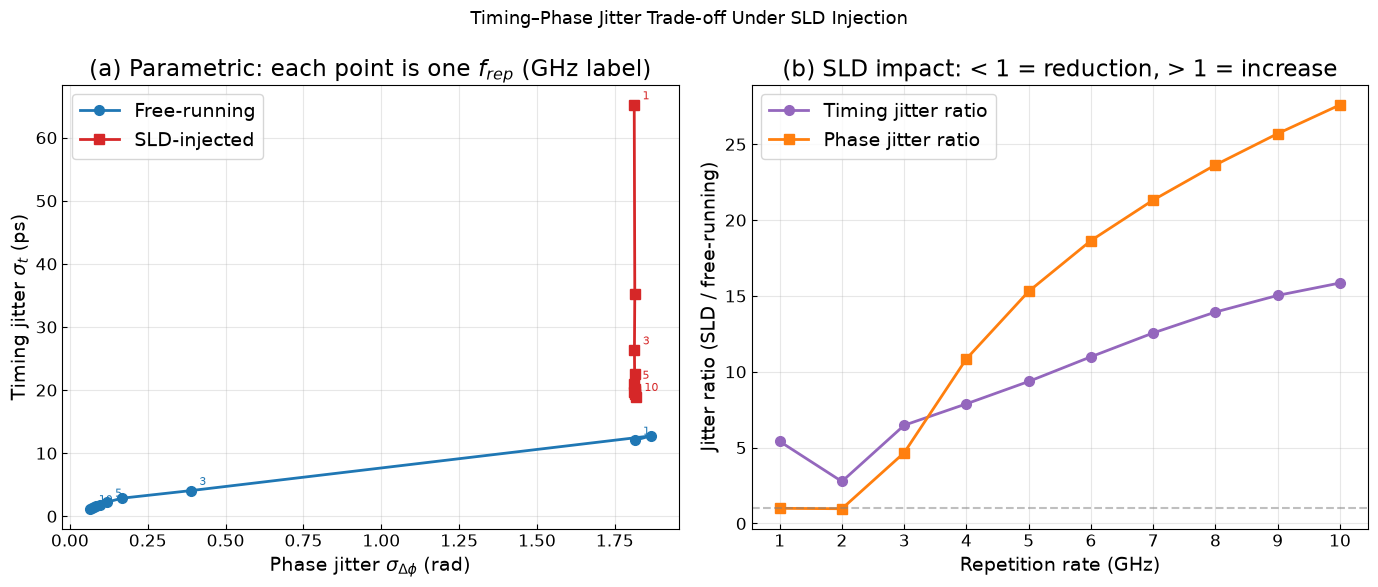

In [160]:
# ─── Timing–phase jitter trade-off — Tweakable ────────────────
TJ3_FIGSIZE    = (14, 6)
TJ3_MS         = 7
TJ3_LW         = 2
TJ3_ANNOT_GHZ  = [1, 3, 5, 10]   # label these points
TJ3_DPI        = 150
TJ3_SAVE       = False
# ───────────────────────────────────────────────────────────────

fig_tj3, axes_tj3 = plt.subplots(1, 2, figsize=TJ3_FIGSIZE)
fig_tj3.suptitle(
    'Timing–Phase Jitter Trade-off Under SLD Injection', fontsize=13)

# (a) Parametric: sig_t vs sig_phi
ax = axes_tj3[0]
for case, color, marker, label in [
    ('free', 'C0', 'o', 'Free-running'),
    ('sld', 'C3', 's', 'SLD-injected'),
]:
    sig_t = [tj_data[f"{f:.0f}GHz_{case}"]['sig_t'] * 1e12
             for f in tj_f_ghz]
    sig_p = [tj_data[f"{f:.0f}GHz_{case}"]['sig_phi']
             for f in tj_f_ghz]
    ax.plot(sig_p, sig_t, f'{marker}-', color=color, lw=TJ3_LW,
            ms=TJ3_MS, label=label)
    for i, fg in enumerate(tj_f_ghz):
        if fg in TJ3_ANNOT_GHZ:
            ax.annotate(f'{fg:.0f}', (sig_p[i], sig_t[i]),
                        textcoords="offset points",
                        xytext=(6, 4), fontsize=8, color=color)

ax.set_xlabel('Phase jitter $\\sigma_{\\Delta\\phi}$ (rad)')
ax.set_ylabel('Timing jitter $\\sigma_t$ (ps)')
ax.set_title('(a) Parametric: each point is one $f_{rep}$ (GHz label)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

# (b) Jitter ratio (SLD / free)
ax = axes_tj3[1]
ratio_t = []
ratio_phi = []
for fg in tj_f_ghz:
    st_f = tj_data[f"{fg:.0f}GHz_free"]['sig_t']
    st_s = tj_data[f"{fg:.0f}GHz_sld"]['sig_t']
    sp_f = tj_data[f"{fg:.0f}GHz_free"]['sig_phi']
    sp_s = tj_data[f"{fg:.0f}GHz_sld"]['sig_phi']
    ratio_t.append(st_s / max(st_f, 1e-30))
    ratio_phi.append(sp_s / max(sp_f, 1e-30))

ax.plot(tj_f_ghz, ratio_t, 'o-', color='C4', lw=TJ3_LW, ms=TJ3_MS,
        label='Timing jitter ratio')
ax.plot(tj_f_ghz, ratio_phi, 's-', color='C1', lw=TJ3_LW, ms=TJ3_MS,
        label='Phase jitter ratio')
ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Repetition rate (GHz)')
ax.set_ylabel('Jitter ratio (SLD / free-running)')
ax.set_xticks(tj_f_ghz)
ax.set_title('(b) SLD impact: < 1 = reduction, > 1 = increase')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', direction='in')

plt.tight_layout()
if TJ3_SAVE:
    fig_tj3.savefig(TJ_OUT / 'jitter_tradeoff.png', dpi=TJ3_DPI, bbox_inches='tight')
    print(f'Saved: {TJ_OUT}/jitter_tradeoff.png')
plt.show()

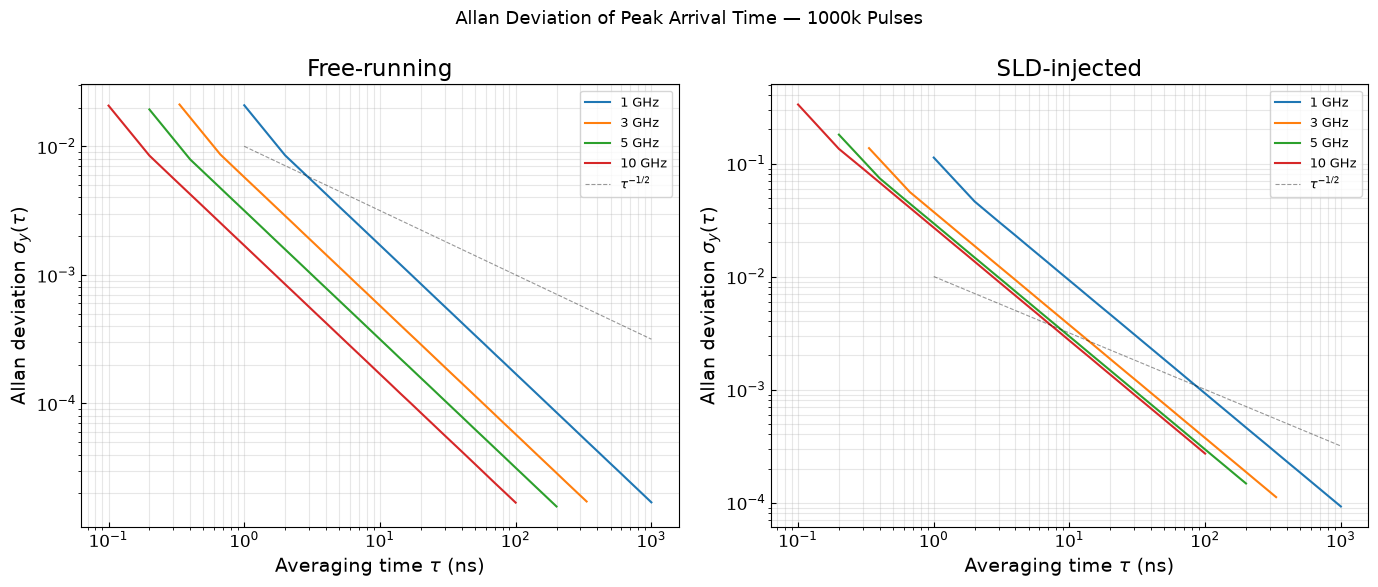

In [161]:
# ─── Allan deviation — Tweakable ───────────────────────────────
TJ4_SEL_GHZ = [1, 3, 5, 10]      # frequencies to show
TJ4_FIGSIZE  = (14, 6)
TJ4_LW       = 1.5
TJ4_DPI      = 150
TJ4_SAVE     = False
# ───────────────────────────────────────────────────────────────

fig_tj4, axes_tj4 = plt.subplots(1, 2, figsize=TJ4_FIGSIZE)
fig_tj4.suptitle(
    f'Allan Deviation of Peak Arrival Time — {tj_N//1000}k Pulses',
    fontsize=13)

for ax, (case, label) in zip(axes_tj4, [
    ('free', 'Free-running'), ('sld', 'SLD-injected')
]):
    for fg in TJ4_SEL_GHZ:
        key = f"{fg}GHz_{case}"
        d = tj_data[key]
        tau_s = d['tau_ad']
        ax.loglog(tau_s * 1e9, d['adev'], lw=TJ4_LW,
                  label=f'{fg} GHz')

    tau_ref = np.array([1e-9, 1e-6])
    ax.loglog(tau_ref * 1e9,
              0.01 * np.sqrt(tau_ref[0] / tau_ref),
              'k--', lw=0.8, alpha=0.4, label='$\\tau^{-1/2}$')

    ax.set_xlabel('Averaging time $\\tau$ (ns)')
    ax.set_ylabel('Allan deviation $\\sigma_y(\\tau)$')
    ax.set_title(label)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', direction='in')

plt.tight_layout()
if TJ4_SAVE:
    fig_tj4.savefig(TJ_OUT / 'allan_deviation.png', dpi=TJ4_DPI, bbox_inches='tight')
    print(f'Saved: {TJ_OUT}/allan_deviation.png')
plt.show()